In [3]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
HDDL — Mini-projet 2 — Conditional VAEs
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Dataset - FashionMNIST
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Analyse Exploratoire des données</span>
            </a>
        </li>
        <ul style="list-style-type: circle; padding-left: 60px;">
            <li style="margin-bottom: 8px;">
            <a href="#11" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.1</span>
                <span style="color: #2c3e50; font-weight: 600;">Préparation des données</span>
            </a>
        </li>
            <li style="margin-bottom: 8px;">
            <a href="#12" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.2</span>
                <span style="color: #2c3e50; font-weight: 600;">Exploration des données</span>
            </a>
        </li>
        </ul>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Qu'est-ce qu'un CVAE et quelle est la différence avec un VAE classique ?</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Création d'un VAE</span>
            </a>
        </li>
        <ul style="list-style-type: circle; padding-left: 60px;">
            <li style="margin-bottom: 8px;">
            <a href="#31" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.1</span>
                <span style="color: #2c3e50; font-weight: 600;">Fonction de perte</span>
            </a>
        </li>
        </ul>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">Entraînement du VAE</span>
            </a>
        </li>
        <ul style="list-style-type: circle; padding-left: 60px;">
            <li style="margin-bottom: 8px;">
            <a href="#41" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.1</span>
                <span style="color: #2c3e50; font-weight: 600;">Entrainement pour différentes valeurs de beta</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#42" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.2</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualisation des espaces latents en fonction de beta</span>
            </a>
        </li>
         <li style="margin-bottom: 8px;">
            <a href="#43" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.3</span>
                <span style="color: #2c3e50; font-weight: 600;">Choix des hyperparamètres et entrainement du meilleur modèle</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#44" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.4</span>
                <span style="color: #2c3e50; font-weight: 600;">Reconstruction d'une donnée</span>
            </a>
        </li>
        </ul>
        <li style="margin-bottom: 8px;">
            <a href="#50" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">5.</span>
                <span style="color: #2c3e50; font-weight: 600;">Echantillonage avec le CVAE</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [1]:
import torch,torchvision,torchaudio
import numpy as np
import matplotlib.pyplot as plt 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Analyse Exploratoire
</h2>

<div id="11"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
1.1 Préparation des données

In [3]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Chargement des datasets
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Vérification rapide
images, labels = next(iter(train_loader))
print("Taille batch :", images.shape)  # [64, 1, 28, 28]
print("Labels :", labels[:10])

Taille batch : torch.Size([128, 1, 28, 28])
Labels : tensor([6, 1, 7, 3, 7, 8, 4, 9, 6, 5])


<div id="12"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
1.2 Exploration des données

In [18]:
class_names = train_dataset.classes
print("Classes de FashionMNIST :")
for i, name in enumerate(class_names):
    print(f"Classe {i}: {name}")

print("-" * 30)

Classes de FashionMNIST :
Classe 0: T-shirt/top
Classe 1: Trouser
Classe 2: Pullover
Classe 3: Dress
Classe 4: Coat
Classe 5: Sandal
Classe 6: Shirt
Classe 7: Sneaker
Classe 8: Bag
Classe 9: Ankle boot
------------------------------


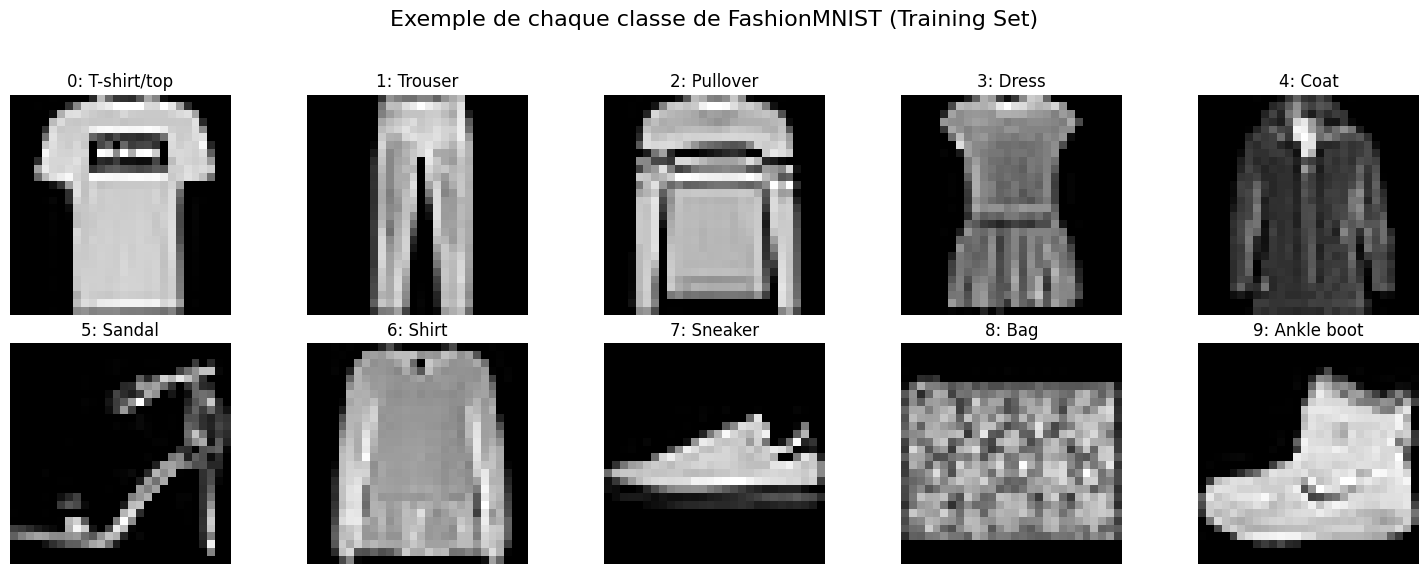

In [19]:
# Affichage d'une image par classe

targets = train_dataset.targets.numpy()
class_indices = {} 
num_classes = len(class_names)

for i in range(num_classes):
    first_index = np.where(targets == i)[0][0] 
    class_indices[i] = first_index


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = class_indices[i]
    label = i
    
    image_tensor, _ = train_dataset[idx]
    

    
    image_display = image_tensor.clone()
    image_display = image_display.squeeze() 
    
    # Affichage
    ax.imshow(image_display.numpy(), cmap='gray')
    ax.set_title(f"{label}: {class_names[label]}")
    ax.axis('off')

plt.suptitle("Exemple de chaque classe de FashionMNIST (Training Set)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuster pour la suptitle
plt.show()

In [20]:
print("-" * 30)
print(f"Taille du jeu d'entraînement: {len(train_dataset)} images")
print(f"Taille du jeu test: {len(test_dataset)} images")
print(f"Taille d'une image: {image_display.shape}")

------------------------------
Taille du jeu d'entraînement: 60000 images
Taille du jeu test: 10000 images
Taille d'une image: torch.Size([28, 28])


### Comptes des classes (Train) ###
Classe 0 (T-shirt/top): 6000
Classe 1 (Trouser): 6000
Classe 2 (Pullover): 6000
Classe 3 (Dress): 6000
Classe 4 (Coat): 6000
Classe 5 (Sandal): 6000
Classe 6 (Shirt): 6000
Classe 7 (Sneaker): 6000
Classe 8 (Bag): 6000
Classe 9 (Ankle boot): 6000

### Comptes des classes (Test) ###
Classe 0 (T-shirt/top): 1000
Classe 1 (Trouser): 1000
Classe 2 (Pullover): 1000
Classe 3 (Dress): 1000
Classe 4 (Coat): 1000
Classe 5 (Sandal): 1000
Classe 6 (Shirt): 1000
Classe 7 (Sneaker): 1000
Classe 8 (Bag): 1000
Classe 9 (Ankle boot): 1000


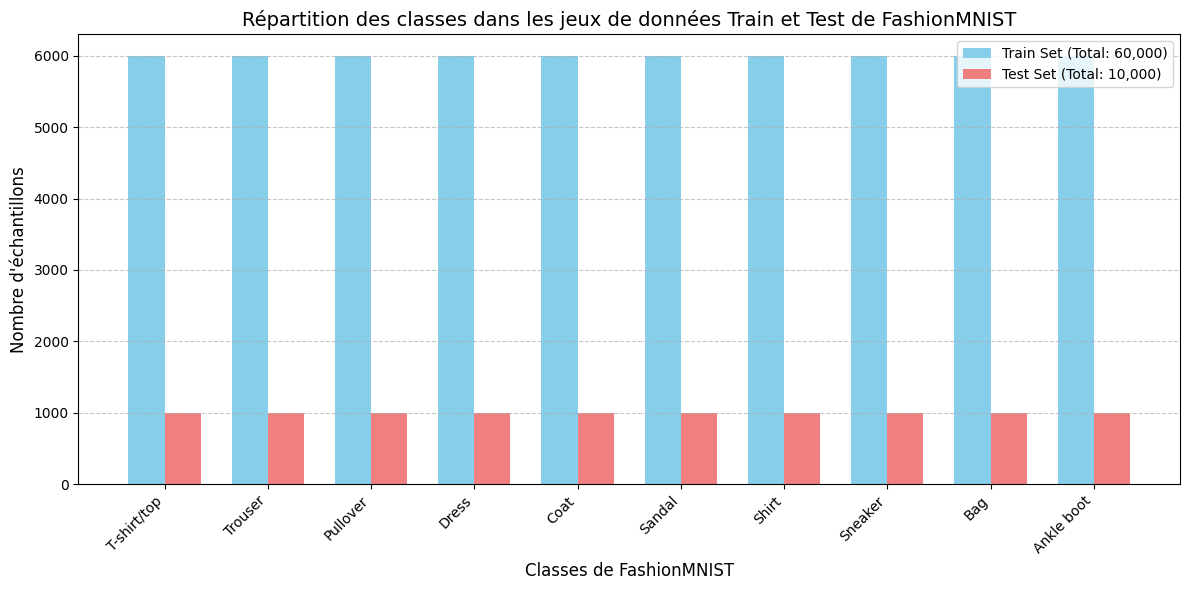

In [21]:
train_targets = train_dataset.targets.numpy()
test_targets = test_dataset.targets.numpy()


# --- 2. Comptage des classes (répartition réelle) ---
# np.unique(..., return_counts=True) retourne un tuple (labels uniques, comptes)
train_classes, train_counts = np.unique(train_targets, return_counts=True)
test_classes, test_counts = np.unique(test_targets, return_counts=True)

print("### Comptes des classes (Train) ###")
for label, count in zip(train_classes, train_counts):
    print(f"Classe {label} ({class_names[label]}): {count}")

print("\n### Comptes des classes (Test) ###")
for label, count in zip(test_classes, test_counts):
    print(f"Classe {label} ({class_names[label]}): {count}")


num_classes = len(class_names)
x = np.arange(num_classes) 
width = 0.35 

fig, ax = plt.subplots(figsize=(12, 6))


rects1 = ax.bar(x - width/2, train_counts, width, 
                label=f'Train Set (Total: {np.sum(train_counts):,})', 
                color='skyblue')


rects2 = ax.bar(x + width/2, test_counts, width, 
                label=f'Test Set (Total: {np.sum(test_counts):,})', 
                color='lightcoral')


ax.set_ylabel("Nombre d\'échantillons", fontsize=12)
ax.set_xlabel('Classes de FashionMNIST', fontsize=12)
ax.set_title('Répartition des classes dans les jeux de données Train et Test de FashionMNIST', fontsize=14)


ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Qu'est-ce qu'un CVAE et quelle est la différence avec un VAE classique ?
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
<strong>Ressources utilisées :</strong> <em>
<br>
https://www.youtube.com/watch?v=e4izCK7l4Kc
<br>https://ijdykeman.github.io/ml/2016/12/21/cvae.html
<br>https://medium.com/data-science/understanding-conditional-variational-autoencoders-cd62b4f57bf8
<br>
Kihyuk Sohn et al, 2015 :https://papers.nips.cc/paper_files/paper/2015/hash/8d55a249e6baa5c06772297520da2051-Abstract.html
<br><br> <em>

Comme nous l'avons vu en cours, les auto-encodeurs variationnels (VAE) sont une méthode non supervisée qui nous permet de générer de nouvelles données. L'encodeur encode les entrées dans un espace latent qui n'est pas constitué de valeurs uniques, mais de distributions de probabilité, plus précisément des distributions gaussiennes $\mathcal{N}(\mu,\sigma^2)$. Pendant la phase d'apprentissage, l'encodeur apprend les paramètres de chaque distribution gaussienne (une par composante latente) qui sont indépendantes, et le décodeur apprend à reconstruire une sortie à partir d'échantillons de ces distributions.

Ensuite, nous pouvons extraire des échantillons de ces distributions gaussiennes et les transmettre au décodeur qui générera de nouvelles données inédites.
<br><br>
L'un des principaux avantages des VAE est qu'ils ne nécessitent pas de labels pour générer des données (méthode non supervisée). Cependant, cela signifie également que nous ne pouvons pas contrôler les échantillons générés. Par exemple, si vous disposez d'un petit ensemble de données labelisées et que vous souhaitez l'augmenter pour entraîner un classifieur, un échantillonnage non contrôlé peut produire de nombreux exemples d'une même classe et biaiser l'ensemble de données augmenté.

Heureusement, il existe un modèle pour résoudre ce problème : les auto-encodeurs variationnels conditionnels (CVAE).
L'architecture d'un CVAE est à peu près la même que celle d'un VAE, sauf que nous alimentons les parties encodeur et décodeur avec le label.


Pour l'exemple des images, l'entrée est $(H,W,3)$, nous devons donc transformer le codage one-hot du label $(N_{label})$ en une forme $(H,W,1)$. Pour ce faire, nous utilisons une couche *Dense* et remodelons sa sortie pour obtenir une représentation image du label. Nous concaténons ensuite les deux entrées pour obtenir l'entrée de l'encodeur qui, ici, sera de forme $(H,W,4)$. Pour le décodeur, l'espace latent est de forme $(latent_{dim})$, nous concaténons donc simplement la représentation du codage one-hot du label avec la représentation latente pour obtenir une entrée du décodeur de forme $(latent_{dim} + N_{label})$.
L'entraînement est similaire à celui d'un VAE. La seule différence avec la perte utilisée pour le VAE est que la distribution de l'encodeur est conditionnée par le label $y$ ainsi que par l'entrée d'image $x$. La fonction de perte comporte deux termes : un terme de reconstruction et un terme de régularisation.
$$
\mathcal{L}(x,\hat x) = \mathcal{L}_{recon}(x,\hat x) + \beta \sum_{j=1}^m KL(q(z_j |x,y) \| \mathcal{N}(0,I)) \text{, où } m \text{ est la dimension cachée}
$$
<br>

 Le terme de reconstruction (par exemple, la cross-entropy ou l'erreur quadratique moyenne, selon la tâche) s'applique entre l'entrée et la reconstruction effectuée par l'autoencodeur. La partie régularisatrice est la divergence de Kullback-Leibler entre la distribution de l'encodeur $\mathcal{N}(\mu,\Sigma)$ (typiquement $\Sigma$ diagonale) et la vraie distribution prior habituellement supposée être $\mathcal{N}(0,I)$. Le paramètre $\beta$ devant la divergence KL est un paramètre qui influencera le modèle. Un grand $\beta$ forcera les $\mu$ et $\Sigma$ à être vraiment proches du vecteur $0$ et de la matrice identité $I$. Cela force le modèle à placer les échantillons d'entraînement dans un sous-espace réduit. Avec une faible valeur de beta, le modèle peut apprendre une meilleure représentation et segmentation des classes mais les valeurs de $\mu$ et $\Sigma$ peuvent varier beaucoup plus, rendant la partie décodeur moins efficace pour l'échantillonnage de données. Nous voulons choisir la valeur de $\beta$ qui nous donne le meilleur compromis entre reconstruction de l'entrée et normalité de l'espace latent.

Une fois l'entraînement terminé, nous pouvons tirer un échantillon de la distribution prior $\mathcal{N}(0,I)$ et indiquer au décodeur pour quel label nous voulons une nouvelle observation (en concaténant le codage one-hot de l'étiquette à l'échantillon) puis alimenter le décodeur avec cela. Si $\beta$ est bien choisi pour que l'espace latent soit gaussien alors il générera des données nouvelles inédites cohérentes.
Cela nous permettra de créer exactement le même nombre d'observations nouvelles pour chaque étiquette et d'avoir un ensemble de données labelisé plus important mais toujours équilibré. Notez que le modèle n'est plus non supervisé (il utilise les labels pendant l'entraînement et la génération), mais il permet une génération contrôlée des données.

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Création d'un CVAE
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Pour l'architecture du CVAE, nous nous sommes inspirés de celle proposée dans la vidéo de Chirag Patil (premier lien dans les ressources au-dessus). C'est une architecture assez simpliste qui pourrait être améliorée, mais qui nous permet de bien comprendre le fonctionnement d'un CVAE et de voir l'influence des hyperparamètres sur les performances du modèle.

On utilise des convolutions avec un stride de 2 plutôt que des poolings pour éviter de perdre l'information de localisation. Au cours du passage dans le CVAE, le nombre de canaux augmente progressivement (32, puis 64 et enfin 128) et la résolution spatiale diminue (28, puis 14, 7 et enfin 4). On utilise ReLU comme fonction d'activation et une Sigmoide en sortie, ce sont les choix traditionnels pour de telles tâches. On applique une normalisation par batch après chaque convolution pour normaliser les activations et donc stabiliser l'entraînement.

In [22]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=10, img_h=28,img_w=28, nb_class=10):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.img_h=img_h
        self.img_w=img_w
        self.nb_class=nb_class
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,64,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128*4*4,latent_dim)
        self.fc_logvar = nn.Linear(128*4*4,latent_dim)

        self.fc_label_encode = nn.Linear(nb_class, img_h * img_w)

        self.fc_decode = nn.Linear(latent_dim+nb_class, 128 * 4 * 4)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), 
            nn.Sigmoid(),
        )

    def encode(self, x, label):
        B = x.size(0)

        one_hot_label=F.one_hot(label, num_classes=self.nb_class).float()
        label_encoding = self.fc_label_encode(one_hot_label)
        label_encoding=F.relu(label_encoding)

        x=x.view(B, 1, self.img_h, self.img_w)
        label_encoding=label_encoding.view(B, 1, self.img_h, self.img_w)

        x=torch.cat([x,label_encoding],1)

        x = self.encoder(x)# Encode the input image
        x = x.view(B, -1) # Flatten the output of the convolutional layers# Flatten the output of the convolutional layers
        
        mu = self.fc_mu(x)# Apply the corresponding FC layer
        logvar = self.fc_logvar(x)# Apply the corresponding FC layer
        return mu, logvar
    

    def sample(self, mu, logvar):
        # Sample z from the Gaussian with the given mu and logvar
        # by using the reparameterization trick: z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    
    def decode(self, z, label):
        
        one_hot_label=F.one_hot(label, num_classes=self.nb_class).float()
        if one_hot_label.dim() == 1:
            one_hot_label = one_hot_label.unsqueeze(0) # Passe de [10] à [1, 10]
        z_cond=torch.cat([z,one_hot_label],1)

        x = self.fc_decode(z_cond)
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x



    def forward(self,x,label):
        x = x.to(device)
        label = label.to(device)

        mu, logvar = self.encode(x,label)
        z = self.sample(mu, logvar)
        return self.decode(z,label), mu, logvar

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Fonction de perte

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Comme présenté dans la partie 2, la fonction de perte est similaire à celle pour les VAE avec une partie de **reconstruction** (ici la cross-entropy comme nous sommes en classification) ainsi qu'une partie de **régularisation**: la divergence de Kullback-Leibler. 

In [23]:
def loss_function(recon_x, x, mu, logvar, beta=1, sep=False):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    if sep:
        return BCE, KLD
    return BCE + beta * KLD

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. Entraînement du CVAE
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On choisit de prendre **2 dimensions latentes** comme nos entrées ne sont pas de trop grande dimension ($28^2 + 10$). Ceci permettra au modèle de ne garder que les informations essentielles des images dans l'espace latent. L'exemple de ce notebook est fait pour illustrer le modèle CVAE et non pour être utilisé dans un but de performance. Ce choix de 2 dimensions latentes nous permettra de parfaitement visualiser ce qu'il se passe dans notre espace latent bien que cela va ensuite nous restreindre dans la génération d'image à cause du manque de diversité dans la simulation de 2 gaussiennes centrées réduites et indépendantes.


<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Entraînement pour différentes valeurs de beta

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
    
Dans ce paragraphe nous allons nous intéresser à l'impact du paramètre $\beta$ de la fonction de perte avec `latent_dim` fixé. Nous savons que ces deux paramètres sont liés. S'il y a plus de dimensions latentes, le modèle pourra conserver plus d'informations dans ces dimensions tout en respectant la contrainte de normalité. Si on baisse le nombre de dimensions latentes, le modèle va vouloir conserver son information sur les données et va donc moins respecter la contrainte de normalité, ainsi il faut augmenter le $\beta$. 
<br> <br>

Nous allons donc regarder l'impact de la valeur de $\beta$ pour 2 dimensions latentes. 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
    
CVAE avec $\beta = 0.01$

In [ ]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

latent_dim = 2
learning_rate = 1e-3
epochs = 5
beta = 0.01


cvae_001=CVAE(latent_dim=latent_dim)
cvae_001.to(device)
optimizer=torch.optim.Adam(cvae_001.parameters(),lr=learning_rate)


# --- Listes pour stocker les mesures ---
train_losses = []
test_losses = []
train_reconstruction_losses = []
train_kld_losses = []
test_reconstruction_losses = []
test_kld_losses = []

## Boucle d'Entraînement et de Test

for epoch in range(1, epochs + 1):
    ### Phase d'Entraînement ###
    cvae_001.train()
    running_loss = 0.0
    running_BCE_loss = 0.0
    running_KLD_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} (Train)', unit='batch')
    
    for batch_idx, (data, label) in enumerate(train_bar):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae_001(data, label)
        loss = loss_function(recon_batch, data, mu, logvar,beta=beta)
        BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_BCE_loss += BCE.item()
        running_KLD_loss += KLD.item()
        
        # Mise à jour de la barre de progression avec la perte actuelle
        train_bar.set_postfix({'Loss': loss.item() / len(data)}) # Perte par échantillon dans le batch
        
    # Calcul de la perte moyenne d'entraînement pour l'époque
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_reconstruction_losses.append(running_BCE_loss / len(train_loader.dataset))
    train_kld_losses.append(running_KLD_loss / len(train_loader.dataset))

    ### Phase de Test / Évaluation ###
    cvae_001.eval()
    test_loss = 0.0
    test_BCE_loss = 0.0
    test_KLD_loss = 0.0
    
    # Pas de calcul de gradient en phase de test
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f'Epoch {epoch}/{epochs} (Test) ', unit='batch')
        for data, label in test_bar:
            data = data.to(device)
            recon_batch, mu, logvar = cvae_001(data, label)
            loss = loss_function(recon_batch, data, mu, logvar,beta=beta)
            BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
            test_loss += loss.item()
            test_BCE_loss += BCE.item()
            test_KLD_loss += KLD.item()
            # Mise à jour de la barre de progression du test
            test_bar.set_postfix({'Loss': loss.item() / len(data)})
            
    # Calcul de la perte moyenne de test pour l'époque
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    test_reconstruction_losses.append(test_BCE_loss / len(test_loader.dataset))
    test_kld_losses.append(test_KLD_loss / len(test_loader.dataset))
    # Affichage récapitulatif de l'époque
    print(f'--- Epoch {epoch}/{epochs} | Training Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} ---\n')

Epoch 1/5 (Train):   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 1/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.29batch/s, Loss=259]


--- Epoch 1/5 | Training Loss: 272.3126 | Test Loss: 253.7597 ---



Epoch 2/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.52batch/s, Loss=257]


--- Epoch 2/5 | Training Loss: 251.1890 | Test Loss: 252.1767 ---



...

--- Epoch 3/5 | Training Loss: 249.2874 | Test Loss: 250.2690 ---



Epoch 4/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 25.24batch/s, Loss=255]


--- Epoch 4/5 | Training Loss: 248.2517 | Test Loss: 250.1108 ---



Epoch 5/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.27batch/s, Loss=254]

--- Epoch 5/5 | Training Loss: 247.7286 | Test Loss: 248.8939 ---



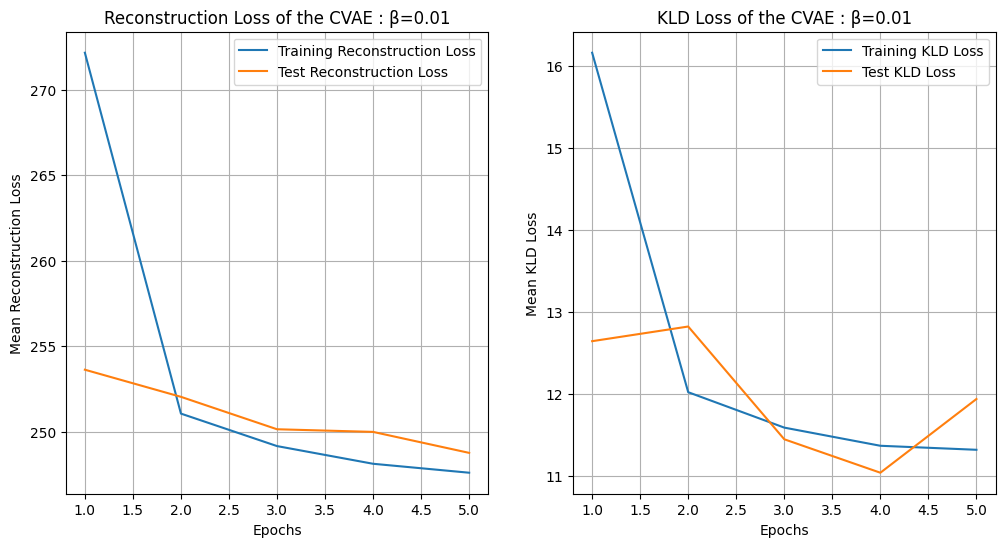

In [46]:
epochs_range = range(1, epochs + 1)
#On fa faire un subplot pour voir les deux composantes de la fonction de perte
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_reconstruction_losses, label='Training Reconstruction Loss')
plt.plot(epochs_range, test_reconstruction_losses, label='Test Reconstruction Loss')
plt.title('Reconstruction Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean Reconstruction Loss')
plt.legend()
plt.grid(True)  


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_kld_losses, label='Training KLD Loss')
plt.plot(epochs_range, test_kld_losses, label='Test KLD Loss')
plt.title('KLD Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean KLD Loss')
plt.legend()
plt.grid(True) 
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Si on affiche les deux termes de la perte (sans prendre en compte le paramètre de régularisation $\beta$), on remarque des valeurs plutôt hautes pour la partie régularisation (Divergence KL). En effet, $\beta$ étant ici faible, le terme de régularisation va être vraiment faible (lorsque l'on multiplie par $\beta$). Le modèle va se focaliser sur la partie reconstruction et va donc chercher à bien reconstruire et séparer les différentes classes plutôt que de chercher à respecter la distribution du prior.

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
    
CVAE avec $\beta = 10$

In [26]:
beta = 10


cvae_10=CVAE(latent_dim=latent_dim)
cvae_10.to(device)
optimizer=torch.optim.Adam(cvae_10.parameters(),lr=learning_rate)


# --- Listes pour stocker les mesures ---
train_losses = []
test_losses = []
train_reconstruction_losses = []
train_kld_losses = []
test_reconstruction_losses = []
test_kld_losses = []

## Boucle d'Entraînement et de Test

for epoch in range(1, epochs + 1):
    ### Phase d'Entraînement ###
    cvae_10.train()
    running_loss = 0.0
    running_BCE_loss = 0.0
    running_KLD_loss = 0.0
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} (Train)', unit='batch')
    
    for batch_idx, (data, label) in enumerate(train_bar):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae_10(data, label)
        loss = loss_function(recon_batch, data, mu, logvar,beta = beta )
        BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_BCE_loss += BCE.item()
        running_KLD_loss += KLD.item()
        
        # Mise à jour de la barre de progression avec la perte actuelle
        train_bar.set_postfix({'Loss': loss.item() / len(data)}) # Perte par échantillon dans le batch
        
    # Calcul de la perte moyenne d'entraînement pour l'époque
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_reconstruction_losses.append(running_BCE_loss / len(train_loader.dataset))
    train_kld_losses.append(running_KLD_loss / len(train_loader.dataset))     
    
    ### Phase de Test / Évaluation ###
    cvae_10.eval()
    test_loss = 0.0
    test_BCE_loss = 0.0
    test_KLD_loss = 0.0
    # Pas de calcul de gradient en phase de test
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f'Epoch {epoch}/{epochs} (Test) ', unit='batch')
        for data, label in test_bar:
            data = data.to(device)
            recon_batch, mu, logvar = cvae_10(data, label)
            loss = loss_function(recon_batch, data, mu, logvar,beta = beta)
            BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
            test_loss += loss.item()
            test_BCE_loss += BCE.item()
            test_KLD_loss += KLD.item()
            # Mise à jour de la barre de progression du test
            test_bar.set_postfix({'Loss': loss.item() / len(data)})
            
    # Calcul de la perte moyenne de test pour l'époque
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    test_reconstruction_losses.append(test_BCE_loss / len(test_loader.dataset))
    test_kld_losses.append(test_KLD_loss / len(test_loader.dataset))

    # Affichage récapitulatif de l'époque
    print(f'--- Epoch {epoch}/{epochs} | Training Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} ---\n')

Epoch 1/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.54batch/s, Loss=291]


--- Epoch 1/5 | Training Loss: 296.0770 | Test Loss: 286.2733 ---



Epoch 2/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.12batch/s, Loss=287]


--- Epoch 2/5 | Training Loss: 280.9088 | Test Loss: 281.9824 ---



Epoch 3/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 27.81batch/s, Loss=285]


--- Epoch 3/5 | Training Loss: 279.3108 | Test Loss: 279.9190 ---



Epoch 4/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 27.13batch/s, Loss=284]


--- Epoch 4/5 | Training Loss: 278.7225 | Test Loss: 279.3086 ---



Epoch 5/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 25.32batch/s, Loss=285]

--- Epoch 5/5 | Training Loss: 278.2278 | Test Loss: 279.2515 ---



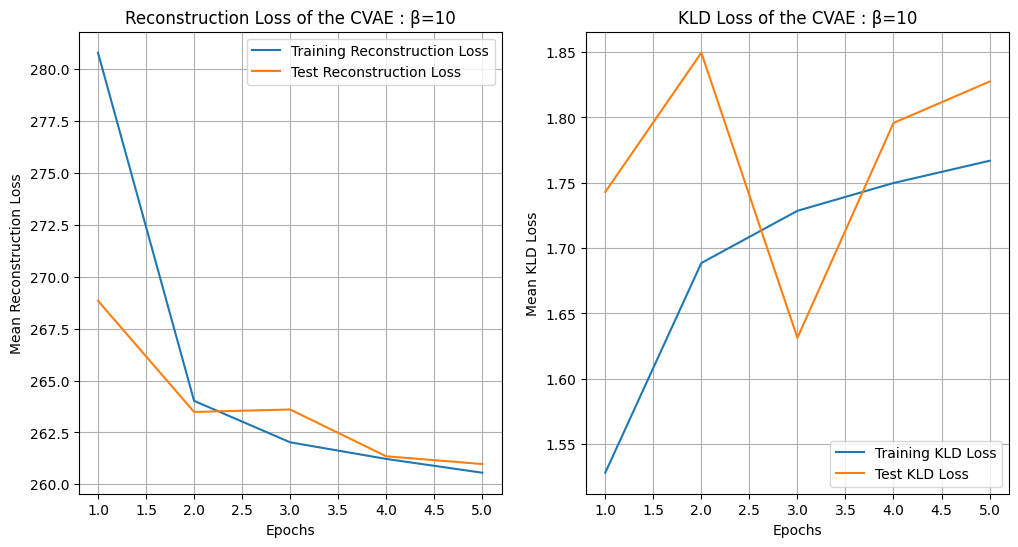

In [27]:
epochs_range = range(1, epochs + 1)
#On fa faire un subplot pour voir les deux composantes de la fonction de perte
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_reconstruction_losses, label='Training Reconstruction Loss')
plt.plot(epochs_range, test_reconstruction_losses, label='Test Reconstruction Loss')
plt.title('Reconstruction Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean Reconstruction Loss')
plt.legend()
plt.grid(True)  


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_kld_losses, label='Training KLD Loss')
plt.plot(epochs_range, test_kld_losses, label='Test KLD Loss')
plt.title('KLD Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean KLD Loss')
plt.legend()
plt.grid(True) 
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Avec $\beta = 10$, on observe que lors de l'entraînement, on observe que les valeurs sont ici plus faibles (facteur 10) par rapport au modèle précédent, indiquant un meilleur respect du prior. Cependant, le modèle ne se force pas à uniquement diminuer la partie régularisation (qui est plus élevé que le modèle précédent si on multiplie par $\beta$) et va chercher également à faire diminuer la partie reconstruction d'où l'augmentation pour la partie régularisation. On en conclut déjà que cette valeur de $\beta$ semble pertinente car le modèle cherche vraiment un compromis aux deux parties de la perte lors de son entraînement.

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
    
CVAE avec $\beta = 100$

In [28]:
beta = 100


cvae_100=CVAE(latent_dim=latent_dim)
cvae_100.to(device)
optimizer=torch.optim.Adam(cvae_100.parameters(),lr=learning_rate)


# --- Listes pour stocker les mesures ---
train_losses = []
test_losses = []
train_reconstruction_losses = []
train_kld_losses = []
test_reconstruction_losses = []
test_kld_losses = []

## Boucle d'Entraînement et de Test

for epoch in range(1, epochs + 1):
    ### Phase d'Entraînement ###
    cvae_100.train()
    running_loss = 0.0
    running_BCE_loss = 0.0
    running_KLD_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} (Train)', unit='batch')
    
    for batch_idx, (data, label) in enumerate(train_bar):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae_100(data, label)
        loss = loss_function(recon_batch, data, mu, logvar,beta = beta )
        BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_BCE_loss += BCE.item()
        running_KLD_loss += KLD.item()
        
        # Mise à jour de la barre de progression avec la perte actuelle
        train_bar.set_postfix({'Loss': loss.item() / len(data)}) # Perte par échantillon dans le batch
        
    # Calcul de la perte moyenne d'entraînement pour l'époque
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_reconstruction_losses.append(running_BCE_loss / len(train_loader.dataset))
    train_kld_losses.append(running_KLD_loss / len(train_loader.dataset))

    ### Phase de Test / Évaluation ###
    cvae_100.eval()
    test_loss = 0.0
    test_BCE_loss = 0.0
    test_KLD_loss = 0.0
    
    # Pas de calcul de gradient en phase de test
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f'Epoch {epoch}/{epochs} (Test) ', unit='batch')
        for data, label in test_bar:
            data = data.to(device)
            recon_batch, mu, logvar = cvae_100(data, label)
            loss = loss_function(recon_batch, data, mu, logvar,beta = beta)
            BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
            test_loss += loss.item()
            test_BCE_loss += BCE.item()
            test_KLD_loss += KLD.item()
            # Mise à jour de la barre de progression du test
            test_bar.set_postfix({'Loss': loss.item() / len(data)})
            
    # Calcul de la perte moyenne de test pour l'époque
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    test_reconstruction_losses.append(test_BCE_loss / len(test_loader.dataset))
    test_kld_losses.append(test_KLD_loss / len(test_loader.dataset))

    # Affichage récapitulatif de l'époque
    print(f'--- Epoch {epoch}/{epochs} | Training Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} ---\n')

Epoch 1/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.69batch/s, Loss=316]


--- Epoch 1/5 | Training Loss: 321.8562 | Test Loss: 310.0935 ---



Epoch 2/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 17.97batch/s, Loss=315]


--- Epoch 2/5 | Training Loss: 308.1370 | Test Loss: 309.3668 ---



Epoch 3/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.84batch/s, Loss=315]


--- Epoch 3/5 | Training Loss: 307.8622 | Test Loss: 309.2814 ---



Epoch 4/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 29.25batch/s, Loss=315]


--- Epoch 4/5 | Training Loss: 307.7093 | Test Loss: 309.0384 ---



Epoch 5/5 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.45batch/s, Loss=315]

--- Epoch 5/5 | Training Loss: 307.6429 | Test Loss: 309.0539 ---



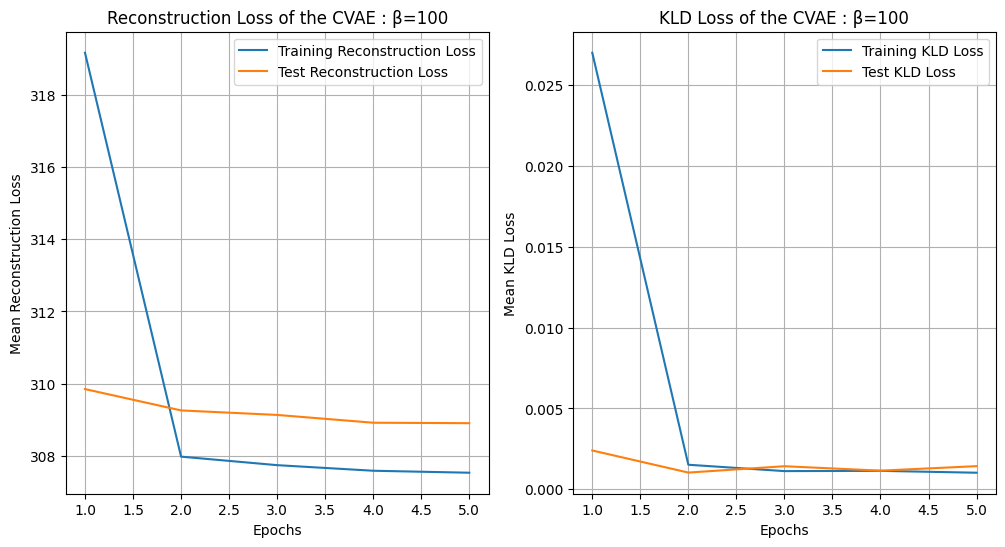

In [29]:
epochs_range = range(1, epochs + 1)
#On fa faire un subplot pour voir les deux composantes de la fonction de perte
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_reconstruction_losses, label='Training Reconstruction Loss')
plt.plot(epochs_range, test_reconstruction_losses, label='Test Reconstruction Loss')
plt.title('Reconstruction Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean Reconstruction Loss')
plt.legend()
plt.grid(True)  


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_kld_losses, label='Training KLD Loss')
plt.plot(epochs_range, test_kld_losses, label='Test KLD Loss')
plt.title('KLD Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean KLD Loss')
plt.legend()
plt.grid(True) 
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Avec $\beta = 100$, on observe des valeurs très faibles pour la partie régularisation et très élevées pour la partie reconstruction. On observe également que la perte de reconstruction ne baisse quasiment plus après la seconde époque. En effet $\beta$ est tellement grand que le modèle se force uniquement à garder le terme de régularisation très faible car sinon la partie de régularisation multipliée par $\beta$ serait beaucoup trop grande et la perte exploserait. On en conclut que se modèle cherche juste à minimiser la Divergence KL et même trop à respecter le prior sans prendre en compte la reconstruction, ce qui va donner un modèle où l'espace latent est trop petit.

<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Visualisation des espaces latents en fonction de beta

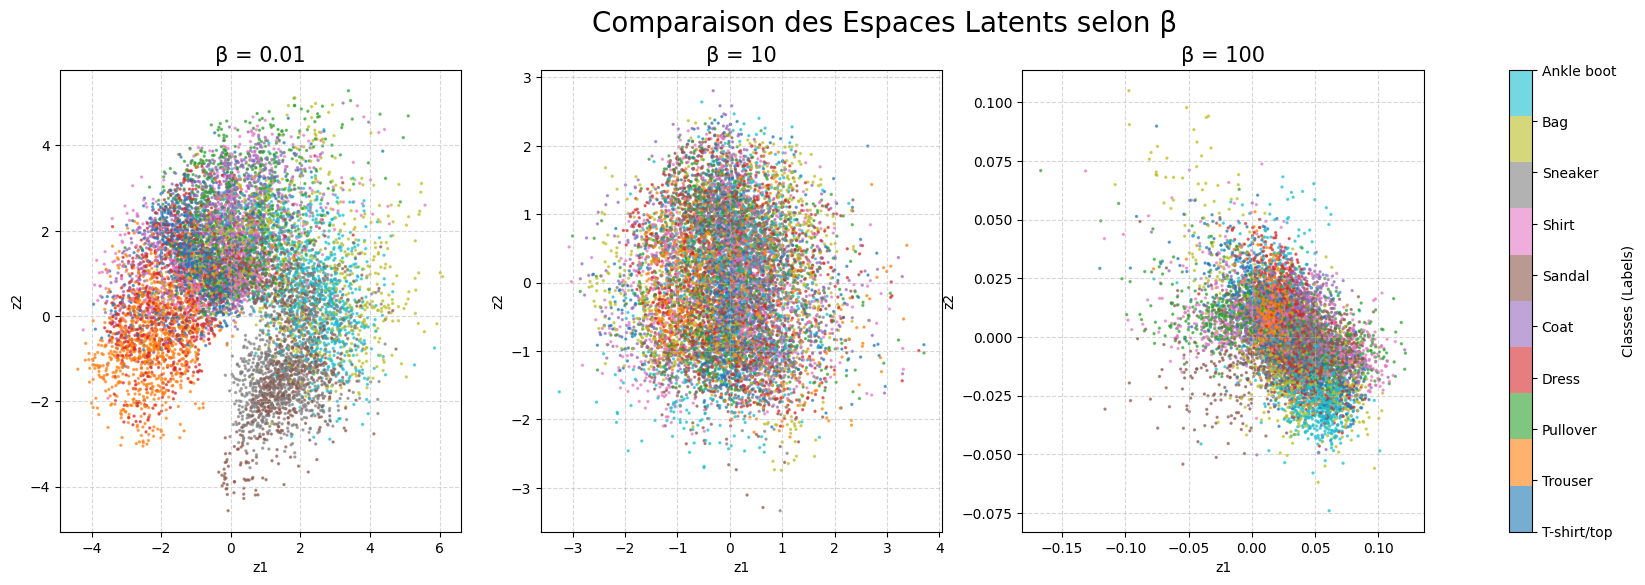

In [30]:
def get_latent_points(model, loader):
    model.eval()
    all_mu = []
    all_labels = []
    
    with torch.no_grad():
        for data, labels in loader:
            data, labels = data.to(device), labels.to(device)
            # On récupère mu (la moyenne) qui sert de coordonnée dans l'espace latent
            mu, _ = model.encode(data, labels) 
            all_mu.append(mu.cpu())
            all_labels.append(labels.cpu())
            
    return torch.cat(all_mu, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

models = [cvae_001, cvae_10, cvae_100] 
beta_values = [0.01, 10, 100]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Comparaison des Espaces Latents selon β", fontsize=20)

for i, model in enumerate(models):
    
    latents, labels = get_latent_points(model, test_loader)
    
    
    ax = axes[i]
    scatter = ax.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.6, s=2)
    
    ax.set_title(f"β = {beta_values[i]}", fontsize=15)
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.grid(True, linestyle='--', alpha=0.5)

# Ajout d'une barre de couleur commune pour les classes
cbar = fig.colorbar(scatter, ax=axes, ticks=range(10), label='Classes (Labels)')
cbar.ax.set_yticklabels(class_names)

plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Avec ce plot, on observe que quand la valeur de $\beta$ est trop petite, trop d'importance est accordée à la partie reconstruction/séparation des classes. Le modèle cherche ici davantage à séparer les classes et bien reconstruire l'image plutôt que de créer un espace latent proche d'une $\mathcal{N}(0,I_2)$. Si on zoome sur une classe (par exemple "trouser"), on voit que les données sont dans un petit sous-espace qui ne recouvre pas du tout le "support" (les valeurs généralement prises) d'une $\mathcal{N}(0,I_2)$ à savoir $[-2,2] $. Ceci va poser problème lors de la génération de nouvelles données. En effet, si notre simulation de $\mathcal{N}(0,I_2)$ atterit trop loin de ce sous-espace la nouvelle donnée sera incohérente et si elle atterit dedans, elle sera trop généraliste.
<br>

Lorsque la valeur de $\beta$ est trop élevée, trop d'importance est accordée au fait de coller à une $\mathcal{N}(0,I_2)$ et par conséquent, tous les données sont concentrées autour de 0. Les données d'entrainement ne sont pas du tout bien réparties sur le "support" d'une $\mathcal{N}(0,I_2)$. Ainsi, lorsque l'on va vouloir générer des nouvelles données en échantillonant avec une $\mathcal{N}(0,I_2)$ , il se peut qu'on arrive dans une zone de l'espace que le modèle ne connaît pas très bien voir pas du tout ou au contraire là où trop de données sont concentrées. La nouvelle donnée risque soit d'être incohérente soit trop généraliste.
<br>

Avec une valeur de $\beta$ du bon ordre de grandeur (ici 10), on observe que les classes sont chacunes bien réparties sur le "support" de la $\mathcal{N}(0,I_2)$  permettant à la génération d'avoir des nouvelles données cohérentes pour chaque classe peu importe la simulation de la $\mathcal{N}(0,I_2)$.
<br>
On retrouve bien les mêmes interprétations sur nos modèles qu'on avait avec les courbes de pertes.

Nous rappelons que ceci n'est valable que pour 2 dimensions latentes avec nos données. Si l'on change le nombre de dimensions latentes, la valeur de $\beta$ optimale va changer et l'on doit refaire cette analyse pour la trouver. Avec plus de dimensions latentes, on peut répartir plus d'informations sur les différentes dimensions tout en respectant la contrainte de normalité. Ainsi, si on augmente le nombre de dimensions, la valeur de $\beta$ optimale diminuera.

Ainsi, dans notre cas, nous allons décider de prendre $\beta = 10$ pour entraîner notre modèle final.

<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Choix des hyperparamètres et entrainement du meilleur modèle

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On va donc entraîner un modèle avec 2 dimensions latentes et $\beta=10$. <br>

On a choisi des batchs de taille 128, une puissance de 2 qui permet donc l'optimisation de la parallélisation via CUDA. On prend une taille pas trop élevée non plus pour ne pas saturer la mémoire sur des petits GPUs (pour nos machines personnelles). <br>

On a choisi l'optimiseur Adam qui offre un très bon compromis entre rapidité de convergence et robustesse. Couplé avec un learning rate de 0.001, valeur de référence pour cet optimiseur, il permet une bonne convergence du modèle. <br>

On a choisi de faire 30 époques d'entrainement car on observe que la perte sur le jeu de test se stabilise après une vingtaine d'époques. Au delà, le modèle risque de sur-apprendre les données d'entrainement et de moins bien généraliser. <br>

In [31]:
latent_dim = 2
learning_rate = 1e-3
epochs = 30
beta = 10

## Boucle d'Entraînement et de Test
train_losses = []
test_losses = []
train_reconstruction_losses = []
train_kld_losses = []
test_reconstruction_losses = []
test_kld_losses = []
cvae_opt=CVAE(latent_dim=latent_dim).to(device)
optimizer=torch.optim.Adam(cvae_opt.parameters(),lr=learning_rate)

for epoch in range(1, epochs + 1):
    ### Phase d'Entraînement ###
    cvae_opt.train()
    running_loss = 0.0
    running_BCE_loss = 0.0
    running_KLD_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} (Train)', unit='batch')
    
    for batch_idx, (data, label) in enumerate(train_bar):
        data = data.to(device)
        label = label.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae_opt(data, label)
        loss = loss_function(recon_batch, data, mu, logvar,beta = beta)
        BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_BCE_loss += BCE.item()
        running_KLD_loss += KLD.item()
        # Mise à jour de la barre de progression avec la perte actuelle
        train_bar.set_postfix({'Loss': loss.item() / len(data)}) # Perte par échantillon dans le batch
        
    # Calcul de la perte moyenne d'entraînement pour l'époque
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_reconstruction_losses.append(running_BCE_loss / len(train_loader.dataset))
    train_kld_losses.append(running_KLD_loss / len(train_loader.dataset))

    ### Phase de Test / Évaluation ###
    cvae_opt.eval()
    test_loss = 0.0
    test_BCE_loss = 0.0
    test_KLD_loss = 0.0
    # Pas de calcul de gradient en phase de test
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f'Epoch {epoch}/{epochs} (Test) ', unit='batch')
        for data, label in test_bar:
            data = data.to(device)
            label = label.to(device)
            recon_batch, mu, logvar = cvae_opt(data, label)
            loss = loss_function(recon_batch, data, mu, logvar,beta = beta)
            BCE ,  KLD = loss_function(recon_batch, data, mu, logvar,beta=beta, sep=True)
            test_loss += loss.item()
            test_BCE_loss += BCE.item()
            test_KLD_loss += KLD.item()
            # Mise à jour de la barre de progression du test
            test_bar.set_postfix({'Loss': loss.item() / len(data)})
            
    # Calcul de la perte moyenne de test pour l'époque
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    test_reconstruction_losses.append(test_BCE_loss / len(test_loader.dataset))
    test_kld_losses.append(test_KLD_loss / len(test_loader.dataset))

    # Affichage récapitulatif de l'époque
    print(f'--- Epoch {epoch}/{epochs} | Training Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} ---\n')

Epoch 1/30 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.06batch/s, Loss=288]


--- Epoch 1/30 | Training Loss: 293.2907 | Test Loss: 283.3808 ---



Epoch 2/30 (Test) : 100%|██████████| 10/10 [00:00<00:00, 26.45batch/s, Loss=287]


--- Epoch 2/30 | Training Loss: 280.4173 | Test Loss: 283.1864 ---



Epoch 3/30 (Test) : 100%|██████████| 10/10 [00:00<00:00, 29.09batch/s, Loss=287]


...

--- Epoch 28/30 | Training Loss: 275.7554 | Test Loss: 277.4546 ---



Epoch 29/30 (Test) : 100%|██████████| 10/10 [00:00<00:00, 27.36batch/s, Loss=282]


--- Epoch 29/30 | Training Loss: 275.6518 | Test Loss: 277.3043 ---



Epoch 30/30 (Test) : 100%|██████████| 10/10 [00:00<00:00, 28.57batch/s, Loss=282]

--- Epoch 30/30 | Training Loss: 275.7036 | Test Loss: 277.2565 ---



In [32]:
#Save the model
torch.save(cvae_opt.state_dict(),"cvae.pt")
#Load the model
#cvae = CVAE(latent_dim)
#cvae.load_state_dict(torch.load("cvae.pt",map_location=torch.device("cpu"),weights_only=True))

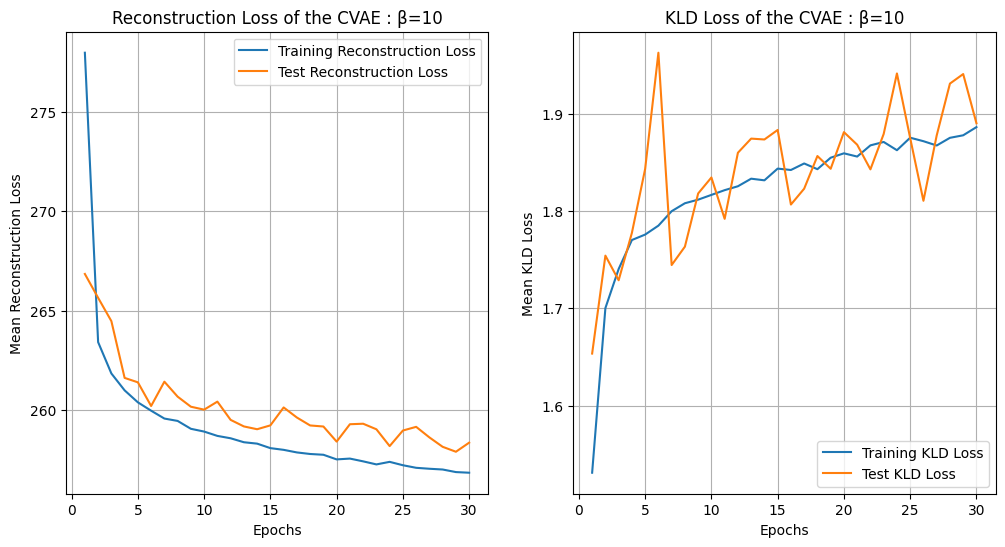

In [33]:
epochs_range = range(1, epochs + 1)
#On fa faire un subplot pour voir les deux composantes de la fonction de perte
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_reconstruction_losses, label='Training Reconstruction Loss')
plt.plot(epochs_range, test_reconstruction_losses, label='Test Reconstruction Loss')
plt.title('Reconstruction Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean Reconstruction Loss')
plt.legend()
plt.grid(True)  


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_kld_losses, label='Training KLD Loss')
plt.plot(epochs_range, test_kld_losses, label='Test KLD Loss')
plt.title('KLD Loss of the CVAE : β={}'.format(beta))
plt.xlabel('Epochs')
plt.ylabel('Mean KLD Loss')
plt.legend()
plt.grid(True) 
plt.show()

<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.4 Reconstruction d'une donnée

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On va ici reconstruire une image via notre CVAE pour vérifier que notre modèle reconstruit correctement nos données mais pas parfaitement non plus à cause de la dimension aléatoire de l'espace latent. 

(28, 28)
(28, 28)


Text(0.5, 1.0, 'Reconstruction')

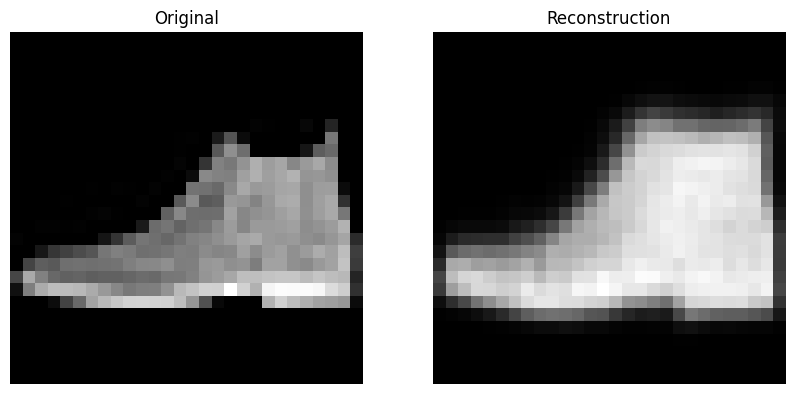

In [34]:
#Reconstruction test
random_images,labels = next(iter(test_loader))

recons, _, _ = cvae_opt(random_images[0].to(device),labels[0].to(device))
# Reshape the images for plotting
random_images = random_images[0].cpu().numpy().squeeze()
recons = recons.detach().cpu().numpy().squeeze()
print(random_images.shape)
print(recons.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
# Plot the original images and their reconstructions
ax[0].imshow(random_images, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Original')

        # Reconstructed images
ax[1].imshow(recons, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Reconstruction')

<div id="50"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    5. Echantillonage avec le CVAE
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On va maintenant générer 5 nouvelles images pour chaque classe en échantillonnant 5 $\mathcal{N}(0,I_2)$ et en indiquant au décodeur pour quelle classe on veut générer une nouvelle image. On ne génère que 5 simulations qu'on va utiliser pour chaque classe afin d'observer l'effet de "style" d'une simulation, c'est à dire que pour une même simulation, on va générer une image de chaque classe et on va observer que la "texture" de l'image est similaire entre les classes (au lieu de générer 50 simulations gaussiennes pour nos 50 nouvelles images).

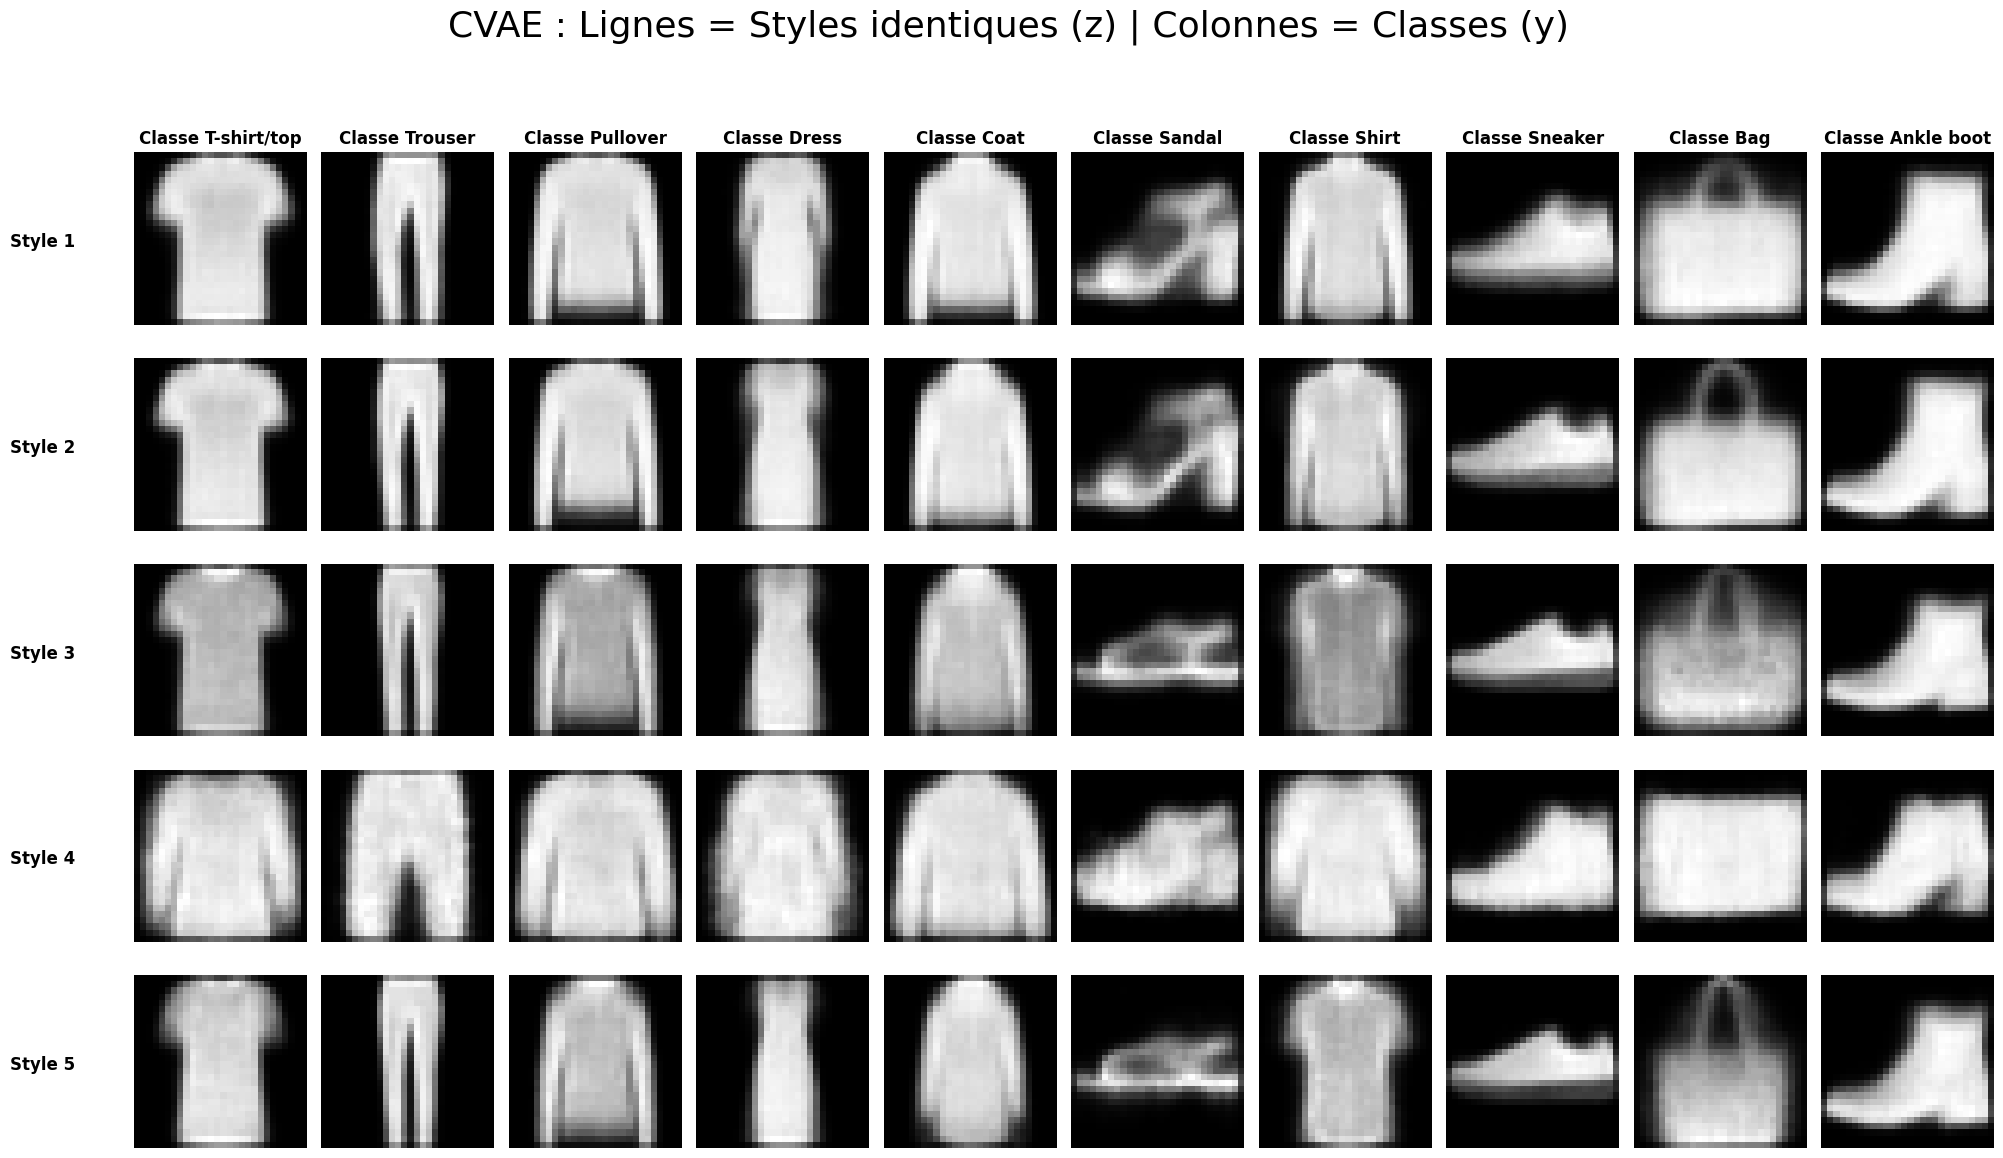

In [44]:
num_styles = 5   # Nombre de lignes (chaque ligne = un z fixe)
num_classes = 10 # Nombre de colonnes (chaque colonne = une classe)

z_styles = torch.randn(num_styles, latent_dim).to(device)

fig, axes = plt.subplots(num_styles, num_classes, figsize=(20, 12))
fig.suptitle('CVAE : Lignes = Styles identiques (z) | Colonnes = Classes (y)', fontsize=26)

cvae_opt.eval()
with torch.no_grad():
    for i in range(num_styles):
        z_current = z_styles[i].unsqueeze(0) 
        # On le répète pour toutes les classes d'un coup pour aller plus vite
        z_batch = z_current.repeat(num_classes, 1)
        
        labels = torch.arange(num_classes).to(device)
        
        generated_images = cvae_opt.decode(z_batch, labels)
        generated_images_np = generated_images.cpu().numpy().squeeze()
        
        for j in range(num_classes):
            ax = axes[i, j]
            ax.imshow(generated_images_np[j], cmap='gray')
            ax.axis('off')
            
            # Afficher le nom de la classe uniquement sur la première ligne
            if i == 0:
                ax.set_title(f"Classe {class_names[j]}", fontsize=12, fontweight='bold')
            
            # Optionnel : Afficher le numéro du style sur la première colonne
            if j == 0:
                ax.text(-10, 14, f"Style {i+1}", va='center', ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88) # Espace pour le titre principal
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On observe bien des styles différents à chaque ligne (les 10 objets de chaque ligne ont été générés avec le même $z$). Par exemple les styles 2 et 5 correspondent à des styles plutôt "classe" avec un T-shirt à col, un pantalon serré, une robe sans manche, gilet à col, des sandales et bottines à talon, ... Le Style 4 correspond à un style "hiver" avec des vêtements chauds et amples, des chaussures hautes. On observe aussi que pour une même simulation, les vêtements générés sont de tailles similaires (si le pantalon est serré, les autres vêtements ont aussi tendance à être plus serrés pour convenir à une personne plus mince). 
<br>

Cependant, on observe que les images générées sont assez floues et assez généralistes. Ceci est dû au fait que nous avons pris un espace latent de très faible dimension (2D) pour pouvoir visualiser l'espace latent. Avec plus de dimensions latentes, le modèle pourrait conserver plus d'informations sur les images et ainsi générer des images plus détaillées. De plus, l'architecture du CVAE est assez simple et pourrait être améliorée pour générer des images de meilleure qualité.